In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
conn = psycopg2.connect(
    dbname="indiaaq", user="postgres",
    password="8765", host="localhost", port="5432"
)

# Quick table check
for table in ['stations', 'raw_measurements', 'clean_measurements', 'daily_features']:
    count = pd.read_sql_query(f"SELECT COUNT(*) FROM {table}", conn).iloc[0, 0]
    print(f"{table}: {count:,} rows")

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/2130714231.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  count = pd.read_sql_query(f"SELECT COUNT(*) FROM {table}", conn).iloc[0, 0]


stations: 724 rows
raw_measurements: 7,780,690 rows
clean_measurements: 7,546,537 rows
daily_features: 47,072 rows


In [3]:
df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: (24477, 23)

Columns: ['date', 'station_id', 'parameter', 'value', 'month', 'day_of_week', 'is_weekend', 'day_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'roll_3_mean', 'roll_7_mean', 'roll_3_std', 'temperature', 'humidity', 'wind_speed', 'no2_value', 'co_value', 'o3_value', 'so2_value', 'created_at']

Null counts:
date               0
station_id         0
parameter          0
value              0
month              0
day_of_week        0
is_weekend         0
day_of_year        0
lag_1              0
lag_2              0
lag_3              0
lag_7              0
roll_3_mean        0
roll_7_mean        0
roll_3_std         0
temperature    15318
humidity       15437
wind_speed     16357
no2_value       2606
co_value        4436
o3_value        3480
so2_value       3661
created_at         0
dtype: int64


/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/3858925908.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)


##### ## 3. Feature Engineering
#####
##### **Key Insight:** Rolling features (roll_3_mean, roll_7_mean, roll_3_std) cause
##### **data leakage** because they include the current day's value.
##### Using them gives R² = 1.0 (perfect but FAKE).
#####
##### **Safe features:** Only use SHIFTED lag values and temporal features.

In [4]:
safe_features = ['month', 'day_of_week', 'is_weekend', 'day_of_year',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7']

# === POLLUTANT FEATURES (low NULLs, fill with median) ===
pollutant_cols = ['no2_value', 'co_value', 'o3_value', 'so2_value']

df_model = df.copy()
for col in pollutant_cols:
    null_pct = df_model[col].isnull().mean() * 100
    df_model[col] = df_model[col].fillna(df_model[col].median())
    print(f"{col}: {null_pct:.1f}% nulls → filled with median")

# Final feature set
FEATURES = safe_features + pollutant_cols
TARGET = 'value'

X = df_model[FEATURES]
Y = df_model[TARGET]

print(f"\nFeatures: {len(FEATURES)} | Rows: {len(X)} | NaN check: {X.isnull().sum().sum()}")

no2_value: 10.6% nulls → filled with median
co_value: 18.1% nulls → filled with median
o3_value: 14.2% nulls → filled with median
so2_value: 15.0% nulls → filled with median

Features: 12 | Rows: 24477 | NaN check: 0


##### 4. Train/Test Split

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 19581 | Test: 4896


##### 5. Model Training & Comparison

In [6]:
# Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train, Y_train)
y_lr = lr.predict(X_test)

#  GradientBoosting (Best)
gb = GradientBoostingRegressor(
    n_estimators=100, max_depth=5,
    learning_rate=0.1, random_state=42
)
gb.fit(X_train, Y_train)
y_gb = gb.predict(X_test)

#  Results 
models = {
    "Linear Regression": y_lr,
    "GradientBoosting":  y_gb,
}

print(f"\n{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 52)
for name, y_pred in models.items():
    mae  = mean_absolute_error(Y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    r2   = r2_score(Y_test, y_pred)
    print(f"{name:<25} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}")


Model                          MAE     RMSE       R²
────────────────────────────────────────────────────
Linear Regression            17.63    30.30   0.7214
GradientBoosting             16.47    28.08   0.7608


##### 6. Feature Importance
#
##### **Key Finding:** `lag_1` (yesterday's PM2.5) carries ~80% of predictive signal.
##### Air pollution is highly autocorrelated.


Feature Importance:
lag_1          0.805160
lag_2          0.047025
day_of_year    0.033913
lag_3          0.033631
lag_7          0.025005
co_value       0.020344
no2_value      0.013387
o3_value       0.008688
so2_value      0.007776
day_of_week    0.002361
month          0.002287
is_weekend     0.000424
dtype: float64

Top feature: lag_1 = 80.5%


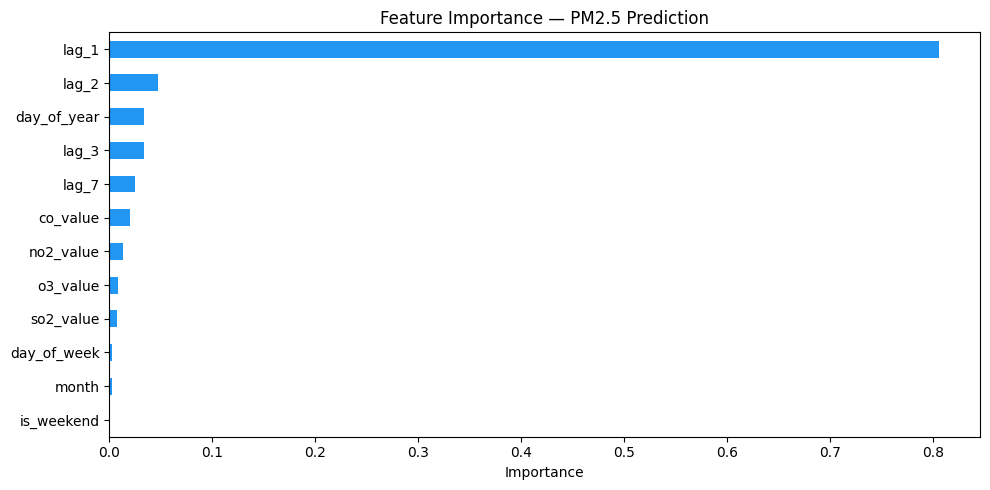

In [7]:
feat_imp = pd.Series(
    gb.feature_importances_, index=FEATURES
).sort_values(ascending=False)

print("Feature Importance:")
print(feat_imp)
print(f"\nTop feature: {feat_imp.index[0]} = {feat_imp.iloc[0]:.1%}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='barh', ax=ax, color='#2196F3')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — PM2.5 Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##### 7. Save Production Model

In [8]:
MODEL_PATH = '../models/gb_pm25_v2_pollutants.pkl'
joblib.dump(gb, MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")
print(f"   R² = {r2_score(Y_test, y_gb):.4f} | MAE = {mean_absolute_error(Y_test, y_gb):.2f}")

✅ Model saved to ../models/gb_pm25_v2_pollutants.pkl
   R² = 0.7608 | MAE = 16.47


##### NASA Power weather data 

In [9]:
nasa = pd.read_csv('../data/weather_nasa_power.csv')

In [10]:
nasa['date'] = pd.to_datetime(nasa['date']).dt.date
print(f"NASA rows: {len(nasa):,}")


NASA rows: 940,704


In [12]:
conn.rollback()
df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)
df['date'] = pd.to_datetime(df['date']).dt.date

df_merged = df.merge(nasa, on=['station_id', 'date'], how='left')

# Use NASA weather (overwrite Open-Meteo's bad data)
df_merged['temperature'] = df_merged['nasa_temperature']
df_merged['humidity'] = df_merged['nasa_humidity']
df_merged['wind_speed'] = df_merged['nasa_wind_speed']
# Check nulls
print(f"\nWeather nulls after NASA merge:")
print(df_merged[['temperature','humidity','wind_speed']].isnull().sum())
print(f"\nTotal rows: {len(df_merged)}")

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/3461689503.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)



Weather nulls after NASA merge:
temperature    3
humidity       3
wind_speed     3
dtype: int64

Total rows: 24477


##### Retraining on new weather data

In [13]:
for col in ['temperature','humidity','wind_speed']:
    df_merged[col] = df_merged[col].fillna(df_merged[col].median())
    
for col in ['no2_value', 'co_value', 'o3_value', 'so2_value']:
    df_merged[col] = df_merged[col].fillna(df_merged[col].median())
# FULL feature set: lags + time + weather + pollutants
full_features = ['month', 'day_of_week', 'is_weekend', 'day_of_year',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7',
                 'temperature', 'humidity', 'wind_speed',
                 'no2_value', 'co_value', 'o3_value', 'so2_value']



In [14]:
X = df_merged[full_features]
Y = df_merged['value']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
gb_final = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_final.fit(X_train, Y_train)
Y_pred = gb_final.predict(X_test)
print(f"MAE:  {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}")
print(f"R²:   {r2_score(Y_test, Y_pred):.4f}")

MAE:  15.94
RMSE: 27.42
R²:   0.7719


In [15]:
feat_imp = pd.Series(gb_final.feature_importances_, index=full_features).sort_values(ascending=False)
print(feat_imp)

# Save the new best model
joblib.dump(gb_final, '../models/gb_pm25_v3_nasa_weather.pkl')
print("\n✅ Best model saved: gb_pm25_v3_nasa_weather.pkl")

lag_1          0.759833
lag_2          0.035823
temperature    0.031417
lag_7          0.025956
lag_3          0.024823
day_of_year    0.022907
wind_speed     0.020758
co_value       0.018909
humidity       0.017516
no2_value      0.015151
o3_value       0.011778
so2_value      0.010528
day_of_week    0.003227
is_weekend     0.000845
month          0.000530
dtype: float64

✅ Best model saved: gb_pm25_v3_nasa_weather.pkl


In [16]:
# CHRONOLOGICAL SPLIT — the REAL test
conn.rollback()
df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)
df['date'] = pd.to_datetime(df['date'])

# Fill nulls
for col in ['temperature','humidity','wind_speed','no2_value','co_value','o3_value','so2_value']:
    df[col] = df[col].fillna(df[col].median())

features = ['month', 'day_of_week', 'is_weekend', 'day_of_year',
            'lag_1', 'lag_2', 'lag_3', 'lag_7',
            'temperature', 'humidity', 'wind_speed',
            'no2_value', 'co_value', 'o3_value', 'so2_value']

# Train on ≤2025, test on 2026
train = df[df['date'] < '2026-01-01']
test  = df[df['date'] >= '2026-01-01']

print(f"Train: {len(train):,} rows (≤2025)")
print(f"Test:  {len(test):,} rows (2026)")

X_train, Y_train = train[features], train['value']
X_test,  Y_test  = test[features],  test['value']

gb_chrono = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_chrono.fit(X_train, Y_train)
Y_pred = gb_chrono.predict(X_test)

print(f"\n--- CHRONOLOGICAL SPLIT (Reality Check) ---")
print(f"MAE:  {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}")
print(f"R²:   {r2_score(Y_test, Y_pred):.4f}")

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/1048922643.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)


Train: 23,924 rows (≤2025)
Test:  553 rows (2026)

--- CHRONOLOGICAL SPLIT (Reality Check) ---
MAE:  17.45
RMSE: 28.35
R²:   0.7746


In [17]:
# === FLAG 1: Check 2026 data ===
print("Data per year:")
print(df.groupby(df['date'].dt.year).size())

# === FLAG 2: Fix pollutant leakage — use LAGGED versions ===
df_fixed = df.copy()
df_fixed = df_fixed.sort_values(['station_id', 'date'])

# Create LAGGED pollutants (yesterday's values, NOT today's)
for col in ['no2_value', 'co_value', 'o3_value', 'so2_value']:
    df_fixed[f'lag_1_{col}'] = df_fixed.groupby('station_id')[col].shift(1)

# Fill NaNs
for col in ['temperature','humidity','wind_speed',
            'lag_1_no2_value','lag_1_co_value','lag_1_o3_value','lag_1_so2_value']:
    df_fixed[col] = df_fixed[col].fillna(df_fixed[col].median())

# PRODUCTION-SAFE features (no same-day pollutants!)
prod_features = ['month', 'day_of_week', 'is_weekend', 'day_of_year',
                 'lag_1', 'lag_2', 'lag_3', 'lag_7',
                 'temperature', 'humidity', 'wind_speed',
                 'lag_1_no2_value', 'lag_1_co_value', 
                 'lag_1_o3_value', 'lag_1_so2_value']

# Chronological split
train = df_fixed[df_fixed['date'] < '2026-01-01']
test  = df_fixed[df_fixed['date'] >= '2026-01-01']

print(f"\nTrain: {len(train):,} (≤2025)")
print(f"Test:  {len(test):,} (2026)")

X_train, Y_train = train[prod_features], train['value']
X_test,  Y_test  = test[prod_features],  test['value']

gb_prod = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_prod.fit(X_train, Y_train)
Y_pred = gb_prod.predict(X_test)

print(f"\n--- PRODUCTION-SAFE (lagged pollutants + chrono split) ---")
print(f"MAE:  {mean_absolute_error(Y_test, Y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}")
print(f"R²:   {r2_score(Y_test, Y_pred):.4f}")

Data per year:
date
2021    16619
2022     2494
2023      215
2024      103
2025     4493
2026      553
dtype: int64

Train: 23,924 (≤2025)
Test:  553 (2026)

--- PRODUCTION-SAFE (lagged pollutants + chrono split) ---
MAE:  16.60
RMSE: 28.23
R²:   0.7765


In [24]:
# Check if raw data has the same gap
raw_by_year = pd.read_sql("""
    SELECT EXTRACT(YEAR FROM datetime_utc) as year, 
           COUNT(*) as rows
    FROM clean_measurements 
    WHERE parameter = 'pm25'
    GROUP BY year 
    ORDER BY year
""", conn)
print(raw_by_year)

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/211579453.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_by_year = pd.read_sql("""


     year    rows
0  2021.0  229709
1  2022.0   48710
2  2023.0    5797
3  2024.0    3000
4  2025.0  482052
5  2026.0   29945


In [23]:
conn.rollback()

In [25]:
# Check how many station-days SHOULD exist
expected = pd.read_sql("""
    SELECT EXTRACT(YEAR FROM datetime_utc) as year,
           COUNT(DISTINCT station_id || '-' || datetime_utc::date) as station_days
    FROM clean_measurements
    WHERE parameter = 'pm25'
    GROUP BY year ORDER BY year
""", conn)
print(expected)

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/1838789012.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  expected = pd.read_sql("""


     year  station_days
0  2021.0         20442
1  2022.0          3125
2  2023.0           267
3  2024.0           123
4  2025.0          7710
5  2026.0           866


##### Year wise pm25 & pm 10 distribution

In [26]:
conn.rollback()

new_dsit = pd.read_sql("""
       SELECT
            EXTRACT(YEAR FROM date) as year,
            parameter,
            COUNT(*) as rows
        FROM daily_features
        GROUP BY year, parameter
        ORDER BY parameter, year                
""", conn)

print(new_dsit)

      year parameter   rows
0   2021.0      pm10  18695
1   2022.0      pm10   2910
2   2024.0      pm10    104
3   2025.0      pm10   5325
4   2026.0      pm10    311
5   2021.0      pm25  19293
6   2022.0      pm25   2961
7   2023.0      pm25    261
8   2024.0      pm25    121
9   2025.0      pm25   6247
10  2026.0      pm25    784


/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/3715144797.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  new_dsit = pd.read_sql("""


##### how many pm25 rows have weather data 

In [27]:
weather_check = pd.read_sql("""
                        SELECT
                            COUNT(*) as total_rows,
                            COUNT(temperature) as has_weather,
                            COUNT(*) - COUNT(temperature) as missing
                        FROM daily_features
                        WHERE parameter = 'pm25'
""", conn)

print(weather_check)

   total_rows  has_weather  missing
0       29667        28773      894


/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/1500547248.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  weather_check = pd.read_sql("""


##### Full-retrain on new updated date & split 

In [28]:
conn.rollback()

df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)

df['date'] = pd.to_datetime(df['date'])

print(f"Total PM25 rows: {len(df):,}")
print(f"\nYear distribution:")
print(df.groupby(df['date'].dt.year).size())

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/1473553678.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)


Total PM25 rows: 29,667

Year distribution:
date
2021    19293
2022     2961
2023      261
2024      121
2025     6247
2026      784
dtype: int64


##### Sorting & creating lagged pollutants

In [30]:
df = df.sort_values(['station_id', 'date'])
for col in ['no2_value', 'co_value', 'o3_value', 'so2_value']:
    df[f'lag_1_{col}'] = df.groupby('station_id')[col].shift(1)
    
features = ['month', 'day_of_week', 'is_weekend', 'day_of_year',
            'lag_1', 'lag_2', 'lag_3', 'lag_7',
            'temperature', 'humidity', 'wind_speed',
            'lag_1_no2_value', 'lag_1_co_value', 
            'lag_1_o3_value', 'lag_1_so2_value']

# Chronological split
train = df[df['date'] < '2026-01-01'].dropna(subset=['value','lag_1'])
test  = df[df['date'] >= '2026-01-01'].dropna(subset=['value','lag_1'])

# Fill ALL feature NaNs before training
for col in features:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())  # use TRAIN median for test
    

print(f"Train NaN: {train[features].isnull().sum().sum()}")
print(f"Test NaN:  {test[features].isnull().sum().sum()}")


gb = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb.fit(train[features], train['value'])
Y_pred = gb.predict(test[features])


print(f"\n{'='*50}")
print(f"PRODUCTION-SAFE (bigger data + chrono + lagged pollutants)")
print(f"MAE:  {mean_absolute_error(test['value'], Y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test['value'], Y_pred)):.2f}")
print(f"R²:   {r2_score(test['value'], Y_pred):.4f}")
print(f"{'='*50}")

Train NaN: 0
Test NaN:  0

PRODUCTION-SAFE (bigger data + chrono + lagged pollutants)
MAE:  17.34
RMSE: 32.27
R²:   0.7044


### New Features to improve Model accuracy

##### 1 precipitation + wind Direction

In [35]:
nasa_extra = pd.read_csv('../data/weather_nasa_power_extra.csv')

nasa_extra['date'] = pd.to_datetime(nasa_extra['date']).dt.date
print(f"NASA extra: {len(nasa_extra):,} rows")


NASA extra: 940,704 rows


##### 2 Fire Counts

In [36]:
fires = pd.read_csv('../data/fire_counts_firms.csv')
fires['date'] = pd.to_datetime(fires['date']).dt.date
print(f"Fire data:  {len(fires):,} rows")


Fire data:  590,249 rows


##### 3 Reload daily_features + stations (for lat/lon)

In [38]:
conn.rollback()
df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)
df['date'] = pd.to_datetime(df['date']).dt.date

stations = pd.read_sql("SELECT id, latitude, longitude FROM stations", conn)
print(f"PM25 rows:  {len(df):,}")

/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/3458053396.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM daily_features WHERE parameter = 'pm25'", conn)


PM25 rows:  29,667


/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_41424/3458053396.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stations = pd.read_sql("SELECT id, latitude, longitude FROM stations", conn)


##### merge aal

In [39]:
df = df.merge(nasa_extra, on=['station_id', 'date'], how='left')
df = df.merge(fires, on=['station_id', 'date'], how='left')
df = df.merge(stations, left_on='station_id', right_on='id', how='left', suffixes=('', '_st'))

In [40]:
# Fire count = 0 if no fires detected that day
df['fire_count'] = df['fire_count'].fillna(0)

# Create lagged fire count (yesterday's fires)
df = df.sort_values(['station_id', 'date'])
df['fire_count_lag_1'] = df.groupby('station_id')['fire_count'].shift(1)


# Create lagged pollutants
for col in ['no2_value', 'co_value', 'o3_value', 'so2_value']:
    df[f'lag_1_{col}'] = df.groupby('station_id')[col].shift(1)

In [41]:
#Fill NaNs
fill_cols = ['temperature','humidity','wind_speed','precipitation','wind_direction',
             'fire_count_lag_1','latitude','longitude',
             'lag_1_no2_value','lag_1_co_value','lag_1_o3_value','lag_1_so2_value']
for col in fill_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"\nNull check: {df[fill_cols].isnull().sum().sum()}")
print(f"Total rows: {len(df):,}")


Null check: 0
Total rows: 29,667


##### full retrain with new features + data 

In [ ]:
# FEATURE SET
god_features = [
    # Time
    'month', 'day_of_week', 'is_weekend', 'day_of_year',
    # Lags
    'lag_1', 'lag_2', 'lag_3', 'lag_7',
    # NASA Weather
    'temperature', 'humidity', 'wind_speed',
    # NEW: God-level
    'precipitation',        # rain washes PM2.5
    'wind_direction',       # where pollution comes from
    'fire_count_lag_1',     # yesterday's fires nearby
    'latitude', 'longitude', # spatial context
    # Lagged pollutants
    'lag_1_no2_value', 'lag_1_co_value',
    'lag_1_o3_value', 'lag_1_so2_value'
]

df['date_dt'] = pd.to_datetime(df['date'])

# Chronological split
train = df[df['date_dt'] < '2026-01-01'].dropna(subset=['value','lag_1'])
test  = df[df['date_dt'] >= '2026-01-01'].dropna(subset=['value','lag_1'])

# Fill any remaining NaNs in features
for col in god_features:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Features: {len(god_features)}")

gb_god = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_god.fit(train[god_features], train['value'])
Y_pred = gb_god.predict(test[god_features])

print(f"\n{'='*55}")
print(f"GOD-LEVEL MODEL (all features + chrono split)")
print(f"MAE:  {mean_absolute_error(test['value'], Y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test['value'], Y_pred)):.2f}")
print(f"R²:   {r2_score(test['value'], Y_pred):.4f}")
print(f"{'='*55}")

# Feature importance
feat_imp = pd.Series(gb_god.feature_importances_, index=god_features).sort_values(ascending=False)
print(f"\nFeature Importance:")
print(feat_imp)

Train: 28,883 | Test: 784
Features: 20

🔥 GOD-LEVEL MODEL (all features + chrono split)
MAE:  17.01
RMSE: 31.98
R²:   0.7096

Feature Importance:
lag_1               0.760137
lag_2               0.034805
temperature         0.030904
lag_3               0.023345
day_of_year         0.020686
lag_7               0.019575
wind_speed          0.018440
precipitation       0.017121
wind_direction      0.011736
latitude            0.011207
humidity            0.010965
longitude           0.009486
lag_1_no2_value     0.006172
lag_1_o3_value      0.005950
lag_1_so2_value     0.005396
lag_1_co_value      0.004974
fire_count_lag_1    0.004117
day_of_week         0.003800
month               0.000771
is_weekend          0.000415
dtype: float64


In [43]:
# Check fire seasonality
df['month_num'] = pd.to_datetime(df['date']).dt.month
fire_by_month = df.groupby('month_num')['fire_count'].mean()
print("Average daily fire count by month:")
print(fire_by_month)

# Test set fire activity
test_fires = test['fire_count_lag_1'].describe()
print(f"\nTest set fire_count_lag_1:\n{test_fires}")

Average daily fire count by month:
month_num
1      7.956795
2     18.101369
3     38.326413
4     27.329250
5     11.735838
6      2.116443
7      0.339945
8      0.457711
9      0.707565
10     4.541485
11    10.940476
12    15.159664
Name: fire_count, dtype: float64

Test set fire_count_lag_1:
count     784.000000
mean       24.183673
std        82.042925
min         0.000000
25%         2.000000
50%         5.000000
75%        14.000000
max      1077.000000
Name: fire_count_lag_1, dtype: float64
